<a href="https://colab.research.google.com/github/RohitPoduval1/csci5527-project/blob/main/ResNet50_Baseline_Stanford.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VGGFace Baseline (Stanford CS230)

## Installations/Libraries

In [1]:
!git clone https://github.com/RohitPoduval1/csci5527-project.git

fatal: destination path 'csci5527-project' already exists and is not an empty directory.


In [2]:
# Legacy Keras and VGGFace
!pip install tf-keras
!pip install keras_vggface keras_applications
!pip install kagglehub

import os
# Force tensorflow to use the legacy keras backend
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tf_keras as keras
import sys
import kagglehub

# Patch for VGGFace
sys.modules['keras.utils.data_utils'] = tf.keras.utils
sys.modules['keras.utils.layer_utils'] = tf.keras.utils
keras.utils.data_utils = tf.keras.utils
keras.utils.layer_utils = tf.keras.utils

sys.modules['keras'] = keras
sys.modules['keras.engine'] = keras.src.engine
sys.modules['keras.engine.topology'] = keras.utils

from keras_vggface.vggface import VGGFace
from tf_keras.models import load_model
from tf_keras.preprocessing.image import ImageDataGenerator
from tf_keras.models import Model
from tf_keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tf_keras.optimizers.legacy import SGD
from tf_keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

# Get dataset
dataset_path = kagglehub.dataset_download("msambare/fer2013")
print("Dataset downloaded successfully!")
print("Path to dataset files:", dataset_path)

TensorFlow Version: 2.20.0
Using Colab cache for faster access to the 'fer2013' dataset.
Dataset downloaded successfully!
Path to dataset files: /kaggle/input/fer2013


## Augmentations, Train/Test

In [3]:
train_dir = os.path.join(dataset_path, 'train')
test_dir = os.path.join(dataset_path, 'test')

# Stanford training augmentations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

# Test set, scaling
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch size 128, 197x197 images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=True,
    class_mode='categorical',
    batch_size=128
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(197, 197),
    color_mode='rgb',
    shuffle=False,
    class_mode='categorical',
    batch_size=128
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


## VGG ResNet50 Transfer Learning

In [4]:
# VGGFace ResNet50 base
vggface_base = VGGFace(model='resnet50', include_top=False, input_shape=(197, 197, 3), pooling='avg')

# Freeze most conv layers, leave batch norm layers trainable
FROZEN_LAYER_NUM = 170
batch_norm_indices = [2, 6, 9, 13, 14, 18, 21, 24, 28, 31, 34, 38, 41, 45, 46, 53, 56, 60, 63, 66, 70, 73, 76, 80, 83, 87, 88, 92, 95, 98, 102, 105, 108, 112, 115, 118, 122, 125, 128, 132, 135, 138, 142, 145, 149, 150, 154, 157, 160, 164, 167, 170]

for i in range(FROZEN_LAYER_NUM):
    if i not in batch_norm_indices:
        vggface_base.layers[i].trainable = False


# Classification head
last_layer = vggface_base.get_layer('avg_pool').output
x = Flatten(name='flatten')(last_layer)
x = Dropout(0.5)(x)
x = Dense(4096, activation='relu', name='fc6')(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu', name='fc7')(x)
x = Dropout(0.5)(x)
out = Dense(7, activation='softmax', name='classifier')(x)
model = Model(vggface_base.input, out)

# SGD, nesterov momentum
sgd = SGD(learning_rate=0.01, momentum=0.9, decay=0.0001, nesterov=True)

# Learning rate scheduler
rlrop = ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.5, patience=10, min_lr=0.00001, verbose=1)

model.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
print("Stanford-Replicated TensorFlow Baseline Constructed.")

94694792/94694792 [==============================] - 2s 0us/step
Stanford-Replicated TensorFlow Baseline Constructed.


In [5]:
epochs = 100

print("Starting Baseline Training...")

history = model.fit_generator(
    generator=train_generator,
    validation_data=validation_generator,
    steps_per_epoch=28709 // 128,
    validation_steps=7178 // 128,
    shuffle=True,
    epochs=100,
    callbacks=[rlrop],
    use_multiprocessing=True,
)

# Save tensorflow weights
model.save('tf_stanford_resnet50_baseline.h5')
print("Model saved to tf_stanford_resnet50_baseline.h5")

Starting Baseline Training...


/tmp/ipykernel_7984/2261019389.py:5: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


Epoch 1/100
224/224 [==============================] - 572s 2s/step - loss: 1.8860 - accuracy: 0.3460 - val_loss: 1.8907 - val_accuracy: 0.1715 - lr: 0.0100
Epoch 2/100
224/224 [==============================] - 534s 2s/step - loss: 1.3702 - accuracy: 0.4779 - val_loss: 1.9564 - val_accuracy: 0.1724 - lr: 0.0100
Epoch 3/100
224/224 [==============================] - 486s 2s/step - loss: 1.2737 - accuracy: 0.5201 - val_loss: 1.5065 - val_accuracy: 0.4000 - lr: 0.0100
Epoch 4/100
224/224 [==============================] - 523s 2s/step - loss: 1.2052 - accuracy: 0.5477 - val_loss: 1.1079 - val_accuracy: 0.5822 - lr: 0.0100
Epoch 5/100
224/224 [==============================] - 486s 2s/step - loss: 1.1598 - accuracy: 0.5654 - val_loss: 1.0278 - val_accuracy: 0.6164 - lr: 0.0100
Epoch 6/100
224/224 [==============================] - 484s 2s/step - loss: 1.1220 - accuracy: 0.5813 - val_loss: 1.0182 - val_accuracy: 0.6230 - lr: 0.0100
Epoch 7/100
224/224 [==============================] - 495

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved to tf_stanford_resnet50_baseline.h5


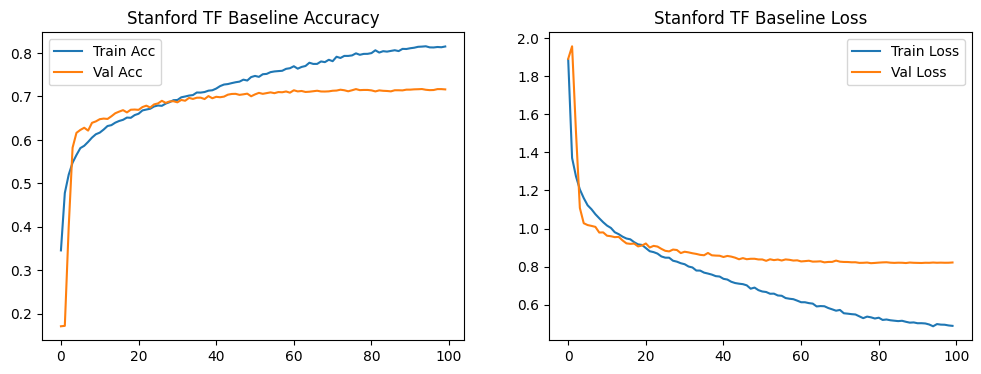

In [6]:
# Plotting the results
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Stanford TF Baseline Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Stanford TF Baseline Loss')
plt.legend()
plt.show()

In [8]:
model_path = 'tf_stanford_resnet50_baseline.h5'

if os.path.exists(model_path):
    print(f"Loading saved model from '{model_path}'...")

    # Load saved weights
    loaded_model = load_model(model_path)

    # Evaluate
    loss, accuracy = loaded_model.evaluate(validation_generator, verbose=1)

    print("\nFinal Evaluation Results")
    print(f"Loss:     {loss:.4f}")
    print(f"Accuracy: {accuracy * 100:.2f}%")
else:
    print(f"Error: Could not find '{model_path}'")

Loading saved model from 'tf_stanford_resnet50_baseline.h5'...
57/57 [==============================] - 26s 419ms/step - loss: 0.8210 - accuracy: 0.7165

Final Evaluation Results
Loss:     0.8210
Accuracy: 71.65%
